# 02 — Energy thematic deep dive

A reviewer-oriented sector drill-down: size and quality, migration/default trend, vulnerable names and stress contribution.

In [1]:
from pathlib import Path
import os
import sys
import yaml
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
from src.data_ingestion import fetch_macro_data, generate_panel
from src.eda_portfolio import latest_snapshot, quarterly_default_rate, watchlist
from src.stress_testing import run as run_stress

with open('config.yaml', encoding='utf-8') as handle:
    config = yaml.safe_load(handle)
macro = fetch_macro_data(config)
panel = generate_panel(1200, seed=config['project']['seed'], macro_df=macro)
current = latest_snapshot(panel)
energy_panel = panel[panel.sector.eq('Energy')].copy()
energy = current[current.sector.eq('Energy')].copy()

## Sector profile

In [2]:
performing = energy[energy.rating.ne('D')]
profile = pd.Series({
    'obligors': energy.obligor_id.nunique(),
    'ead_gbp_bn': energy.ead.sum() / 1e9,
    'portfolio_ead_pct': energy.ead.sum() / current.ead.sum() * 100,
    'performing_wa_pd_pct': np.average(performing.pd, weights=performing.ead) * 100,
    'defaulted_ead_pct': energy.loc[energy.rating.eq('D'), 'ead'].sum() / energy.ead.sum() * 100,
    'secured_ead_pct': energy.loc[energy.seniority.eq('senior_secured'), 'ead'].sum() / energy.ead.sum() * 100,
})
profile.to_frame('result')

,result
obligors,168.000000
ead_gbp_bn,0.831598
portfolio_ead_pct,13.384657
performing_wa_pd_pct,1.537289
defaulted_ead_pct,2.659485
secured_ead_pct,56.693897


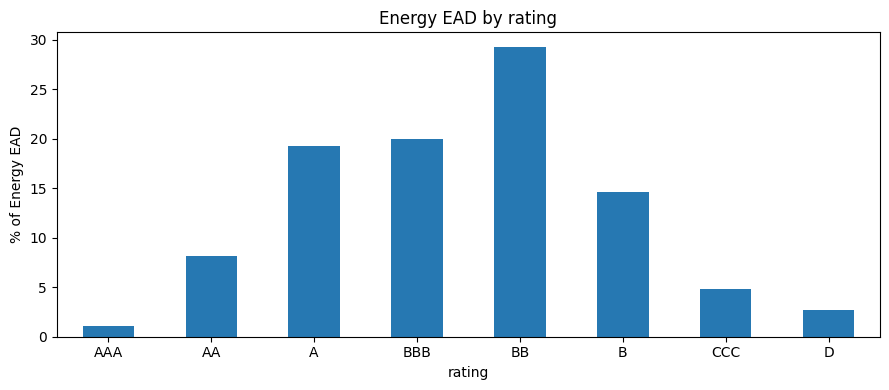

In [3]:
rating_mix = energy.groupby('rating', observed=True).ead.sum().reindex(
    ['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'CCC', 'D'], fill_value=0
) / energy.ead.sum() * 100
rating_mix.plot.bar(figsize=(9, 4), color='#2678B2', title='Energy EAD by rating')
plt.ylabel('% of Energy EAD'); plt.xticks(rotation=0); plt.tight_layout();

## Default trend and stress contribution

In [4]:
energy_defaults = quarterly_default_rate(energy_panel)
energy_defaults.tail(8)

,snapshot_date,n_at_risk,n_defaults,default_rate_pct
15,2022-01-01,154,0,0.000000
16,2022-04-01,154,1,0.649351
17,2022-07-01,153,2,1.307190
18,2022-10-01,151,0,0.000000
19,2023-01-01,151,1,0.662252
20,2023-04-01,150,0,0.000000
21,2023-07-01,150,0,0.000000
22,2023-10-01,150,0,0.000000


In [5]:
stress = run_stress(current, config)
stress['sector_sensitivity'].query("sector == 'Energy'")

,sector,base_el,stressed_el,ead,el_delta,el_delta_pct_ead
1,Energy,1.056828e+07,3.966986e+07,8.315982e+08,2.910158e+07,3.499476


## Names for credit review

In [6]:
energy_watch = watchlist(panel).query("sector == 'Energy'").copy()
columns = ['obligor_id', 'rating', 'ead', 'pd', 'lgd', 'leverage_ratio', 'interest_coverage', 'maturity_date']
energy_watch[columns].sort_values(['rating', 'ead'], ascending=[False, False]).head(15)

,obligor_id,rating,ead,pd,lgd,leverage_ratio,interest_coverage,maturity_date
7174,OBL-00351,CCC,2.128167e+07,0.194627,0.203470,3.906655,5.689768,2030-05-31
18830,OBL-00919,CCC,7.311882e+06,0.189491,0.422959,3.646014,6.297327,2027-06-30
3409,OBL-00168,CCC,6.129330e+06,0.210632,0.233221,4.700121,3.943717,2026-05-31
19593,OBL-00957,CCC,1.983863e+06,0.215071,0.473740,4.804251,3.050640,2028-01-31
10665,OBL-00521,CCC,1.706955e+06,0.208177,0.701383,4.689195,4.634274,2029-07-31
3156,OBL-00156,CCC,1.440834e+06,0.201343,0.249640,4.182374,4.688683,2024-08-31
12454,OBL-00607,BB,8.965996e+06,0.005608,0.241465,3.662980,6.735128,2024-10-31
1118,OBL-00055,BB,3.228011e+06,0.005824,0.262549,3.921329,6.595852,2025-02-28
3919,OBL-00193,BB,1.535387e+06,0.005363,0.190821,3.419940,7.156609,2025-02-28
18026,OBL-00880,B,2.035368e+07,0.024649,0.752799,4.071451,4.493178,2026-03-31


## Credit view

The analytical action is to distinguish broad macro sensitivity from borrower-specific mitigants. The first review queue should combine severe-scenario incremental EL with CCC/B rating, weak coverage and near-term maturity; collateral quality, hedging, covenant headroom and sponsor support then require qualitative assessment.